# Modelo de risco (em R) para o custo de um projeto de um gasoduto.

## Grupo 6

### Nomes

- Bruna Irene da Silva - 119062418
- Davi dos Santos Mattos - 119133049
- Gabriel Mayrink Verdun - 125078427

# Item 1

## Modelagem

In [11]:
install.packages('triangle')
library(triangle)

set.seed(1103) #14

n <- 3000 # Número de Simulações

# Definição da Rota
p_alt <- runif(n, 0.35, 0.45)
rota_alt <- rbinom(n, 1, p_alt)

comprimento_km <- ifelse(rota_alt == 1, 290, 260)

num_secoes <- (comprimento_km * 1000) / 8
num_juncoes <- num_secoes - 1

# Sorteio de Variáveis
tubo <- rtriangle(n, 725, 790, 740)
escavacao_tempo <- rtriangle(n, 12, 25, 16)
mao_obra <- rtriangle(n, 17, 23, 18.5)
transporte <- rtriangle(n, 6.1, 7.4, 6.6)
soldagem <- rtriangle(n, 4, 5, 4.5)
filtro <- rtriangle(n, 165000, 188000, 173000)
acabamento <- rtriangle(n, 14000, 17000, 15000)

# Material
custo_material <- num_secoes * (tubo + transporte)

# Mão de Obra
custo_mao_obra <- num_secoes * escavacao_tempo * mao_obra +
                  num_juncoes * soldagem * mao_obra

# Serviços
custo_servicos <- filtro + comprimento_km * acabamento

# Custo Total
custo_total <- custo_material + custo_mao_obra + custo_servicos


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## Gráficos

### Histograma de Custo Total

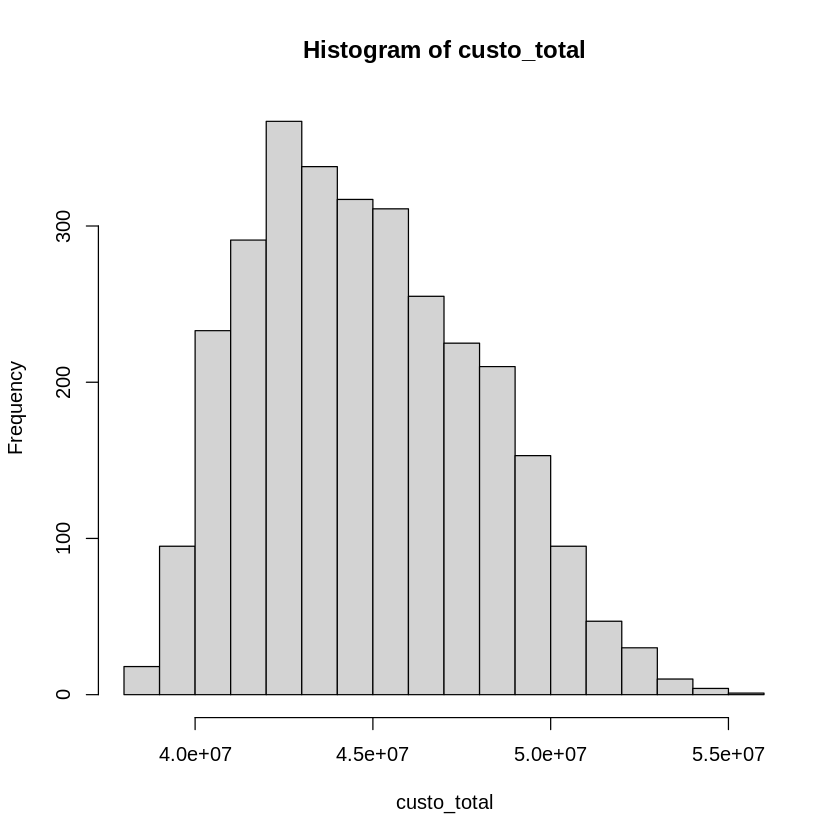

In [12]:
hist(custo_total)

### Histograma separado por tipo de rota

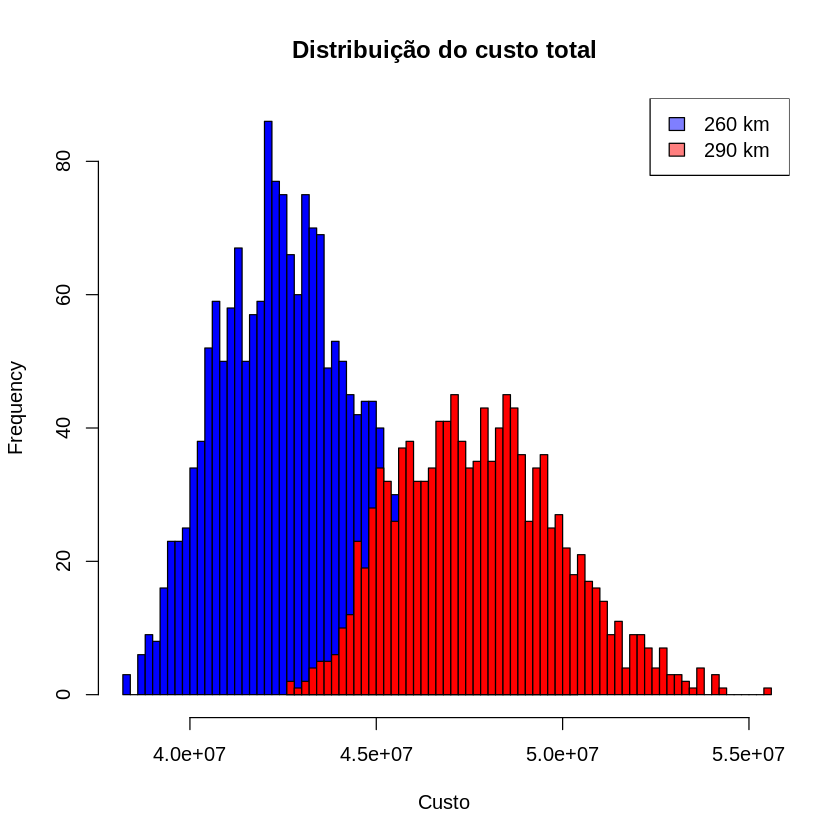

In [13]:
hist(custo_total[rota_alt == 0],
     col="blue",  # azul transparente
     breaks=50,
     main="Distribuição do custo total",
     xlab="Custo",
     xlim=range(custo_total))

hist(custo_total[rota_alt == 1],
     col="red",  # vermelho transparente
     breaks=50,
     add=TRUE)

legend("topright",
       legend=c("260 km", "290 km"),
       fill=c(rgb(0,0,1,0.5), rgb(1,0,0,0.5)))

Conversão de moeda para milhões

In [14]:
# Custo Total
custo_total <- custo_material + custo_mao_obra + custo_servicos
custo_total_milhoes <- custo_total / 1e6
custo_total_260_milhoes <- custo_total[rota_alt == 0] / 1e6
custo_total_290_milhoes <- custo_total[rota_alt == 1] / 1e6

### PMF

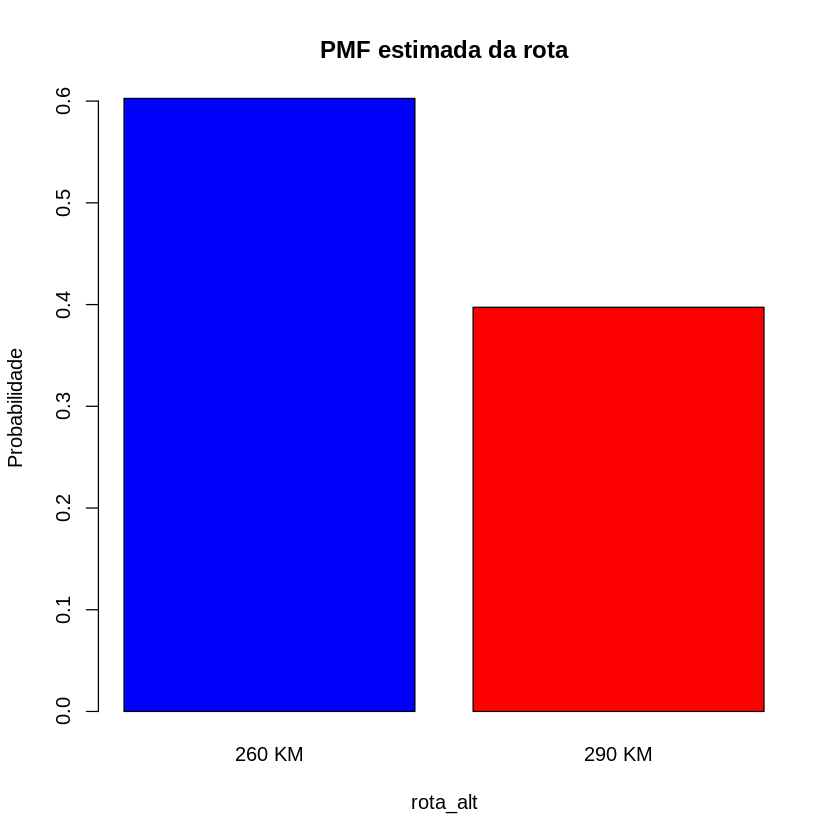

In [15]:
# PMF
pmf_rota_alt <- prop.table(table(rota_alt))
barplot(pmf_rota_alt, col=c("blue", "red"), main="PMF estimada da rota", xlab="rota_alt", ylab="Probabilidade", names.arg=c("260 KM", "290 KM"))


### Histogramas com valores convertidos

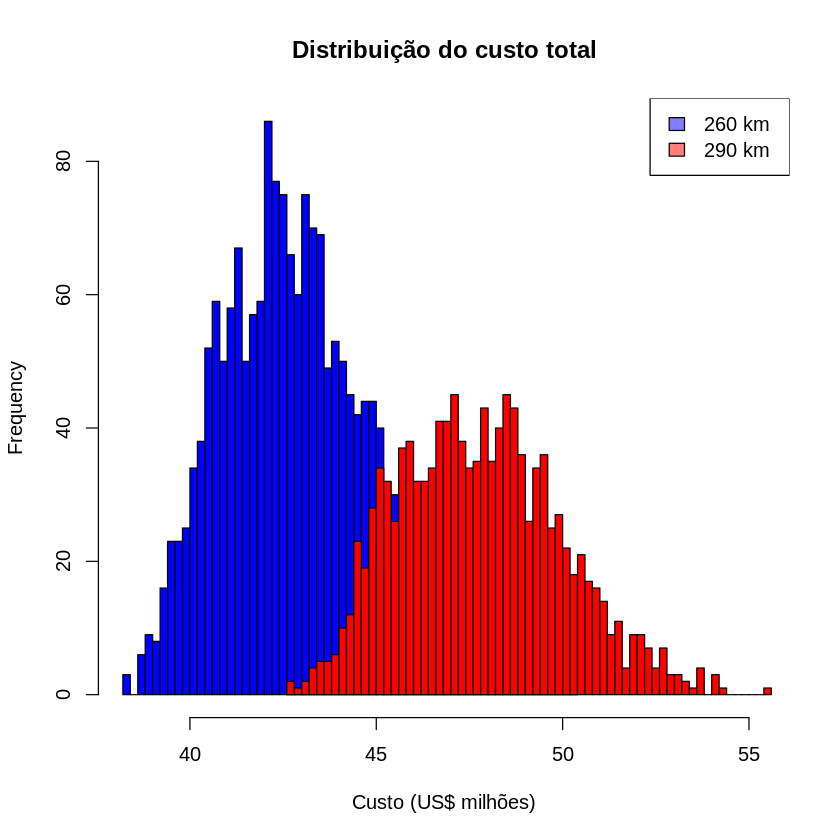

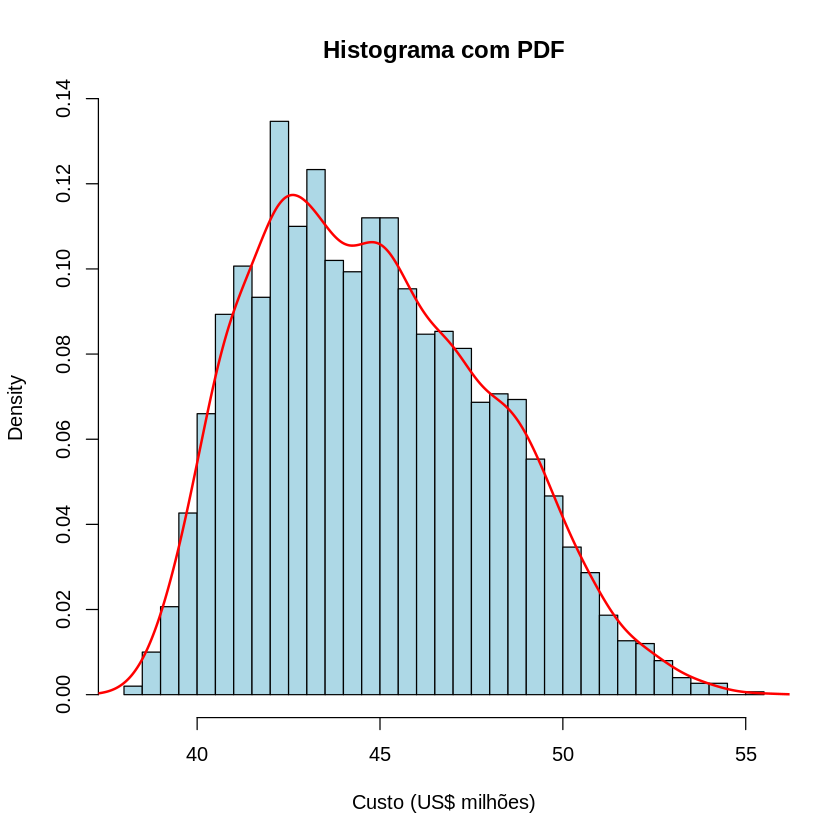

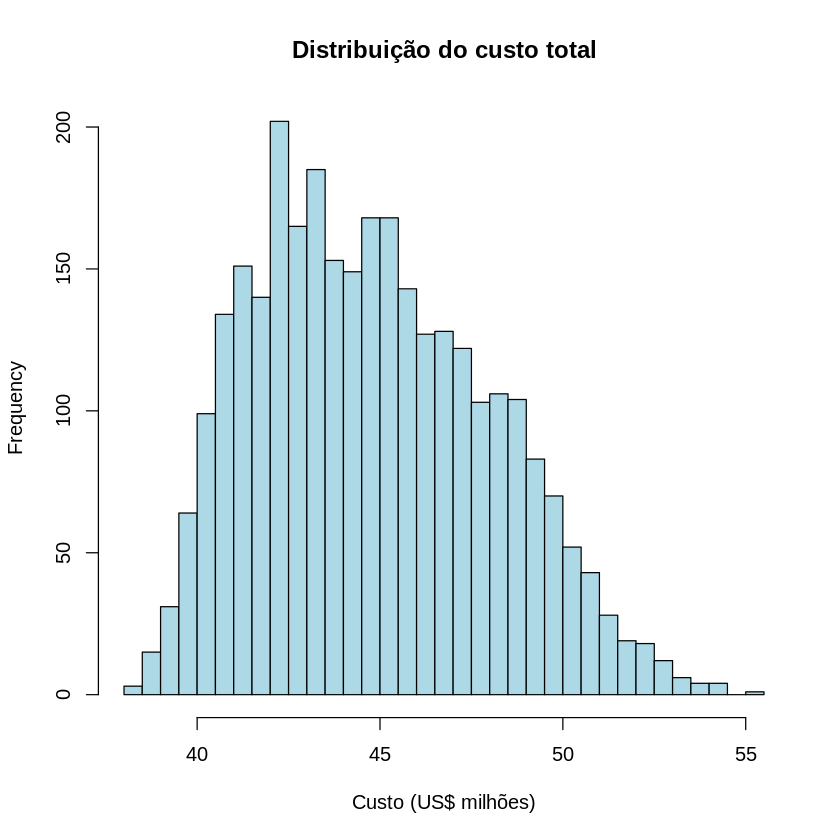

In [16]:
# Histograma comparativo
hist(custo_total_260_milhoes, col="blue", breaks=50, main="Distribuição do custo total", xlab="Custo (US$ milhões)", xlim=range(custo_total_milhoes))
hist(custo_total_290_milhoes, col="red", breaks=50, add=TRUE)
legend("topright", legend=c("260 km", "290 km"), fill=c(rgb(0,0,1,0.5), rgb(1,0,0,0.5)))

custo_total_density <- density(custo_total_milhoes)
custo_total_ecdf <- ecdf(custo_total_milhoes)

# Histograma com PDF
hist(custo_total_milhoes, probability=TRUE, col="lightblue", breaks=50, main="Histograma com PDF", xlab="Custo (US$ milhões)")
lines(custo_total_density, col="red", lwd=2)

# Histograma do custo total
hist(custo_total_milhoes, col="lightblue", breaks=50, main="Distribuição do custo total", xlab="Custo (US$ milhões)")


### PDF e  CDF

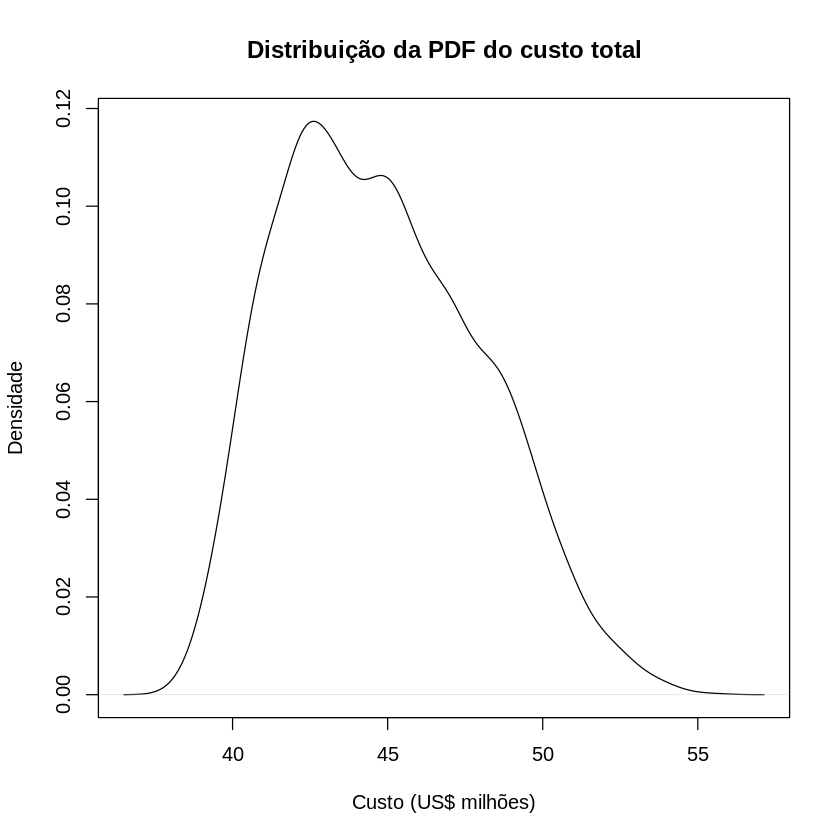

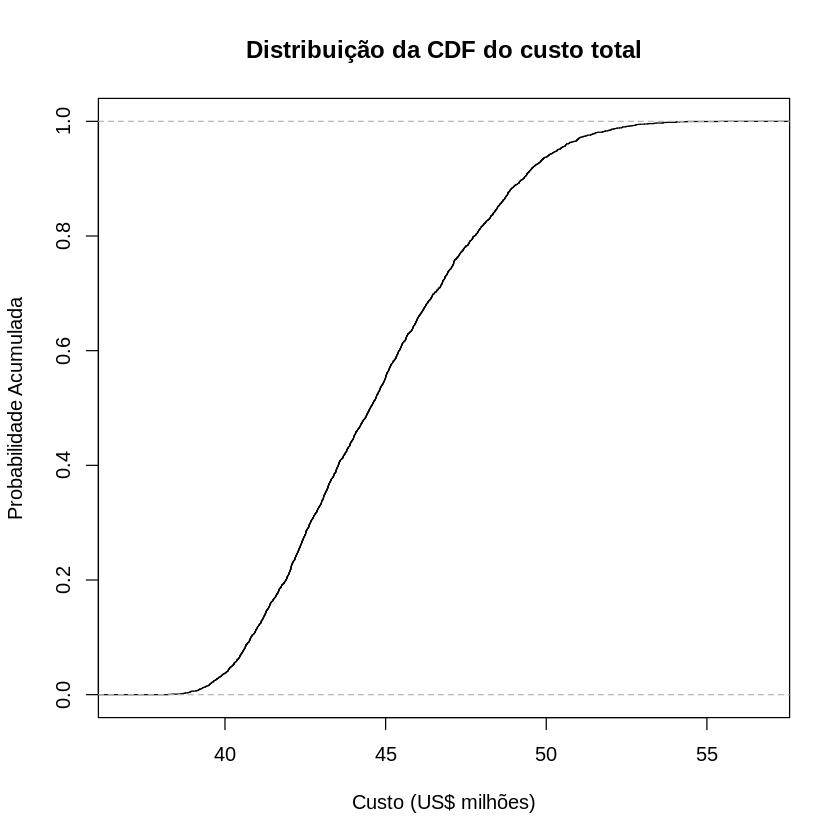

In [17]:
# Gráfico da PDF e CDF
plot(custo_total_density, main="Distribuição da PDF do custo total", xlab="Custo (US$ milhões)", ylab="Densidade")
plot(custo_total_ecdf, main="Distribuição da CDF do custo total", xlab="Custo (US$ milhões)", ylab="Probabilidade Acumulada")

# Item 2

## Estimando Valores

O custo base
foi estabelecido como a mediana (percentil 50%) da distribuição simulada,
representando o custo mais típico/provável do projeto. O preço proposto foi
fixado no percentil 80%, garantindo uma margem de segurança de aproximadamente
80% de chance de não ultrapassar o orçamento estimado.

Resultados
----------

Usando MEDIANA como custo base:
- Custo base (P50) ≃ USD 44,52 milhões
- Preço Proposto(P80) ≃ USD 47,78 milhões
- Contingência ≃ USD 3.26 milhões
- % de Contingência ≃ 7,32% do custo base


In [18]:
summary(custo_total)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
38230853 42280323 44520536 44801447 47097722 55403497 

In [19]:
custo_base <- as.numeric(quantile(custo_total_milhoes, 0.50)) # Custo base (mediana)

preco_proposto <- as.numeric(quantile(custo_total_milhoes, 0.80)) # Preço proposto

contingencia <- preco_proposto - custo_base

percentual_contingencia <- (contingencia / custo_base) * 100

Valores em USD Milhões

In [20]:
custo_base

[1] 44.52054

In [21]:
preco_proposto

[1] 47.76604

In [22]:
contingencia

[1] 3.245499

In [23]:
percentual_contingencia

[1] 7.289892

# Item 3

## Aceitar uma proposta de USD 45M pela obra?

In [24]:
preco_avaliado <- 45 # Proposta a avaliar em milhões

# Cálculo da probabilidade acumulada para o preço de 45 M
prob_ate_45m <- custo_total_ecdf(preco_avaliado)
prob_acima_45m <- 1 - prob_ate_45m

# Comparação com percentis
p50 <- quantile(custo_total_milhoes, 0.50)
p80 <- quantile(custo_total_milhoes, 0.80)
p90 <- quantile(custo_total_milhoes, 0.90)

# Margens
margem_vs_mediana <- preco_avaliado - as.numeric(p50)
deficit_vs_p90 <- preco_avaliado - as.numeric(p80)

# Exibir análise
cat("\n--- ANÁLISE DA PROPOSTA DE USD 45 MILHÕES ---\n")
cat(sprintf("Probabilidade de custo <= 45 M: %.1f%%\n", prob_ate_45m * 100))
cat(sprintf("Probabilidade de custo > 45 M (RISCO): %.1f%%\n", prob_acima_45m * 100))
cat(sprintf("Margem acima da mediana (P50): USD %.2f M\n", margem_vs_mediana))
cat(sprintf("Déficit em relação ao P80: USD %.2f M\n", deficit_vs_p90))
cat(sprintf("\nComparativo:\n"))
cat(sprintf("  P50 (mediana):    USD %.2f M\n", as.numeric(p50)))
cat(sprintf("  P80:              USD %.2f M\n", as.numeric(p80)))
cat(sprintf("  P90 (recomendado): USD %.2f M\n", as.numeric(p90)))
cat(sprintf("  Proposta:         USD %.2f M\n", preco_avaliado))

# Recomendação
if (prob_acima_45m > 0.5) {
  cat("\n*** RECOMENDAÇÃO: REJEITAR a proposta - risco muito alto (>50% chance de estouro) ***\n")
} else if (prob_acima_45m > 0.2) {
  cat("\n*** RECOMENDAÇÃO: RISCO MODERADO a ALTO - Negociar para pelo menos USD ",
      sprintf("%.2f M", as.numeric(p80)), " ***\n", sep="")
} else {
  cat("\n*** RECOMENDAÇÃO: Viável com atenção - Margem pequena ***\n")
}


--- ANÁLISE DA PROPOSTA DE USD 45 MILHÕES ---
Probabilidade de custo <= 45 M: 55.3%
Probabilidade de custo > 45 M (RISCO): 44.7%
Margem acima da mediana (P50): USD 0.48 M
Déficit em relação ao P80: USD -2.77 M

Comparativo:
  P50 (mediana):    USD 44.52 M
  P80:              USD 47.77 M
  P90 (recomendado): USD 49.29 M
  Proposta:         USD 45.00 M

*** RECOMENDAÇÃO: RISCO MODERADO a ALTO - Negociar para pelo menos USD 47.77 M ***


Conclusão: NÃO aceitar, a proposta de USD 45 milhões é INSUFICIENTE e ARRISCADA para o contratante.